# UTS Data Mining — Prediksi Kualitas Anggur (Wine Quality)
**Mata Kuliah:** Data Mining  
**Program Studi:** S1 Pendidikan Matematika  
**Semester:** Genap / 2025-2026  
**Pengampu:** Nur Achmey Selgi Harwanti, S.Stat. M.Stat

---
**Nama: Zaen Khulisatul Makrifah**

**NIM: 2304020031**

**No. Urut: 26**

---

## Deskripsi
Notebook ini mendokumentasikan seluruh proses klasifikasi kualitas anggur mulai dari eksplorasi data, pembersihan, pemilihan model, evaluasi, hingga prediksi data testing. Beberapa algoritma machine learning dicoba dan dibandingkan untuk memilih model terbaik.

**Variabel target:** `quality` (skala 0–10)

---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## 2. Persiapan Data
Dataset terdiri dari dua file:
- `data_training.csv` — digunakan untuk melatih dan mengevaluasi model
- `data_testing.csv` — digunakan untuk prediksi akhir (tidak memiliki label `quality`)

In [2]:
train = pd.read_csv('/content/data_training.csv')
test  = pd.read_csv('/content/data_testing.csv')

print('=== DATASET TRAINING ===')
print(f'Jumlah baris x kolom : {train.shape}')
print(f'Kolom                : {list(train.columns)}')
display(train.head())

print('\n=== DATASET TESTING ===')
print(f'Jumlah baris x kolom : {test.shape}')
print(f'Kolom                : {list(test.columns)}')
display(test.head())

=== DATASET TRAINING ===
Jumlah baris x kolom : (857, 13)
Kolom                : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



=== DATASET TESTING ===
Jumlah baris x kolom : (286, 12)
Kolom                : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


**Interpretasi:** Dataset training memiliki 857 sampel dengan 11 fitur kimiawi dan 1 variabel target (`quality`). Dataset testing memiliki 286 sampel tanpa label `quality` yang akan diprediksi.

---
## 3. Pembersihan Data (Data Cleaning)

### 3.1 Pemeriksaan Missing Values

In [3]:
print('=== MISSING VALUES — TRAINING ===')
mv_train = train.isnull().sum()
print(mv_train)
print(f'\nTotal missing values: {mv_train.sum()}')

print('\n=== MISSING VALUES — TESTING ===')
mv_test = test.isnull().sum()
print(mv_test)
print(f'\nTotal missing values: {mv_test.sum()}')

=== MISSING VALUES — TRAINING ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values: 0

=== MISSING VALUES — TESTING ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

Total missing values: 0


**Interpretasi:** Tidak ditemukan missing values pada kedua dataset, sehingga tidak diperlukan proses imputasi atau penghapusan baris.

### 3.2 Pemeriksaan Tipe Data dan Statistik Deskriptif

In [4]:
print('=== TIPE DATA ===')
print(train.dtypes)
print('\n=== STATISTIK DESKRIPTIF ===')
display(train.describe().round(3))

=== TIPE DATA ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

=== STATISTIK DESKRIPTIF ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,8.262,0.529,0.267,2.506,0.087,15.783,45.978,0.997,3.313,0.657,10.430,5.653,813.749
std,1.702,0.179,0.195,1.294,0.049,10.300,31.692,0.002,0.152,0.167,1.067,0.822,463.807
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.390,8.400,3.000,0.000
25%,7.100,0.395,0.090,1.900,0.070,7.000,21.000,0.996,3.210,0.550,9.500,5.000,413.000
50%,7.900,0.520,0.250,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,814.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,63.000,0.998,3.400,0.730,11.100,6.000,1214.000
max,15.600,1.580,1.000,15.500,0.611,68.000,278.000,1.003,4.010,2.000,14.000,8.000,1597.000


**Interpretasi:** Semua fitur bertipe numerik (float64/int64), tidak ada encoding yang diperlukan. Dari statistik deskriptif terlihat bahwa rentang nilai antar fitur sangat bervariasi — misalnya `total sulfur dioxide` bisa mencapai 272 sedangkan `density` hanya berkisar 0.990–1.004. Perbedaan skala ini mengindikasikan bahwa **feature scaling diperlukan**.

### 3.3 Pemeriksaan Duplikat

In [5]:
print(f'Jumlah data duplikat (training): {train.duplicated().sum()}')
print(f'Jumlah data duplikat (testing) : {test.duplicated().sum()}')

Jumlah data duplikat (training): 0
Jumlah data duplikat (testing) : 0


---
## 4. Eksplorasi Data (EDA)

### 4.1 Distribusi Variabel Target

=== DISTRIBUSI KUALITAS ANGGUR ===
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Rasio kelas mayoritas/minoritas: 60.3x


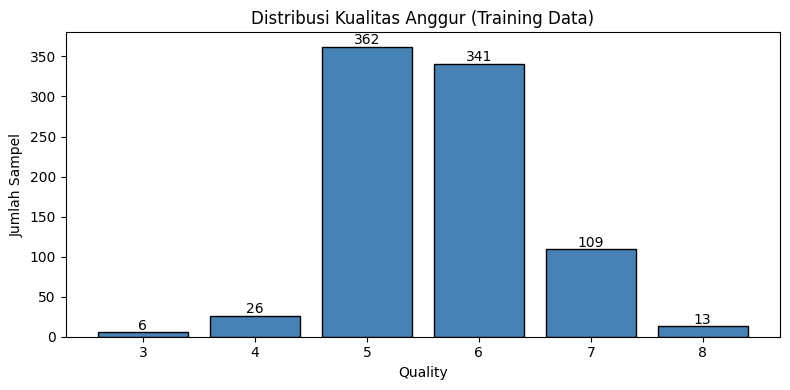

In [6]:
vc = train['quality'].value_counts().sort_index()
print('=== DISTRIBUSI KUALITAS ANGGUR ===')
print(vc)
print(f'\nRasio kelas mayoritas/minoritas: {vc.max()/vc.min():.1f}x')

plt.figure(figsize=(8, 4))
bars = plt.bar(vc.index, vc.values, color='steelblue', edgecolor='black')
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontsize=10)
plt.title('Distribusi Kualitas Anggur (Training Data)')
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
plt.xticks(vc.index)
plt.tight_layout()
plt.show()

**Interpretasi:** Terdapat ketidakseimbangan kelas (*class imbalance*) yang cukup signifikan. Kelas 5 dan 6 mendominasi dengan masing-masing 362 dan 341 sampel, sedangkan kelas 3 hanya memiliki 6 sampel. Rasio antara kelas mayoritas dan minoritas mencapai 60:1. Kondisi ini dapat membuat model cenderung memprediksi kelas mayoritas. Untuk mengatasi hal ini, digunakan model ensemble berbasis pohon (Random Forest, Extra Trees) yang relatif lebih robust terhadap class imbalance.

### 4.2 Korelasi Fitur dengan Target

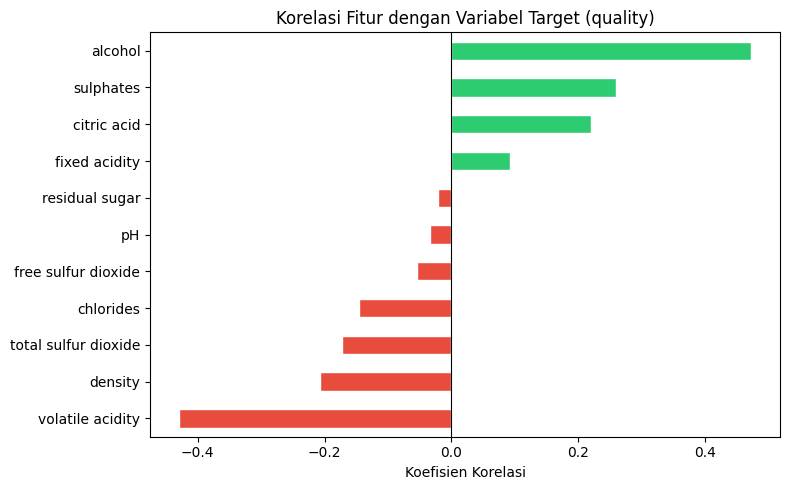

volatile acidity       -0.430
density                -0.208
total sulfur dioxide   -0.173
chlorides              -0.145
free sulfur dioxide    -0.055
pH                     -0.033
residual sugar         -0.021
fixed acidity           0.093
citric acid             0.221
sulphates               0.261
alcohol                 0.474
Name: quality, dtype: float64


In [7]:
features = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

corr_target = train[features + ['quality']].corr()['quality'].drop('quality').sort_values()

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target.values]
corr_target.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur dengan Variabel Target (quality)')
plt.xlabel('Koefisien Korelasi')
plt.tight_layout()
plt.show()

print(corr_target.round(3))

**Interpretasi:** Fitur `alcohol` memiliki korelasi positif tertinggi (0.474) dengan kualitas anggur — semakin tinggi kadar alkohol, cenderung semakin baik kualitasnya. Sebaliknya, `volatile acidity` memiliki korelasi negatif terkuat (-0.430) — semakin tinggi kadar asam volatil, kualitas anggur cenderung lebih rendah. Fitur `residual sugar`, `pH`, dan `free sulfur dioxide` memiliki korelasi yang sangat lemah dengan target.

### 4.3 Heatmap Korelasi Antar Fitur

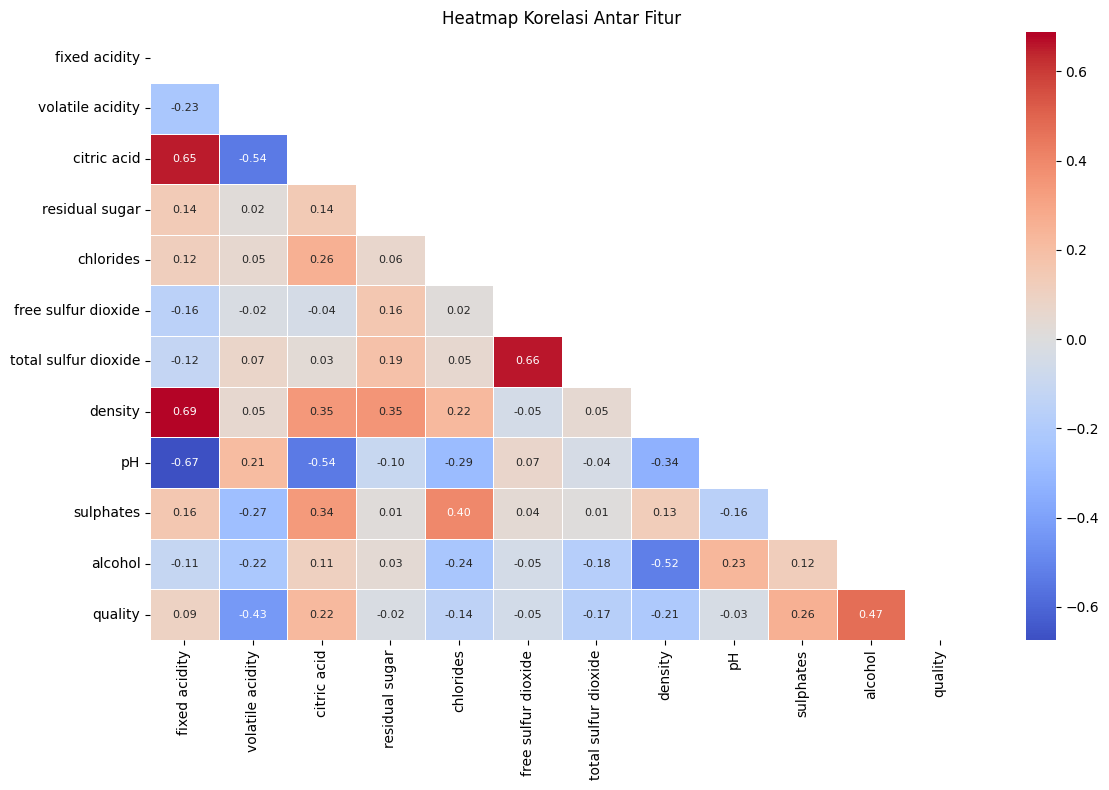

In [8]:
plt.figure(figsize=(12, 8))
corr_matrix = train[features + ['quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

**Interpretasi:** Terdapat beberapa pasangan fitur yang berkorelasi tinggi, misalnya `density` dengan `fixed acidity` dan `total sulfur dioxide` dengan `free sulfur dioxide`. Korelasi antar fitur yang tinggi (*multikolinearitas*) tidak menjadi masalah besar untuk model berbasis pohon seperti Random Forest dan Extra Trees.

### 4.4 Distribusi Setiap Fitur (Boxplot)

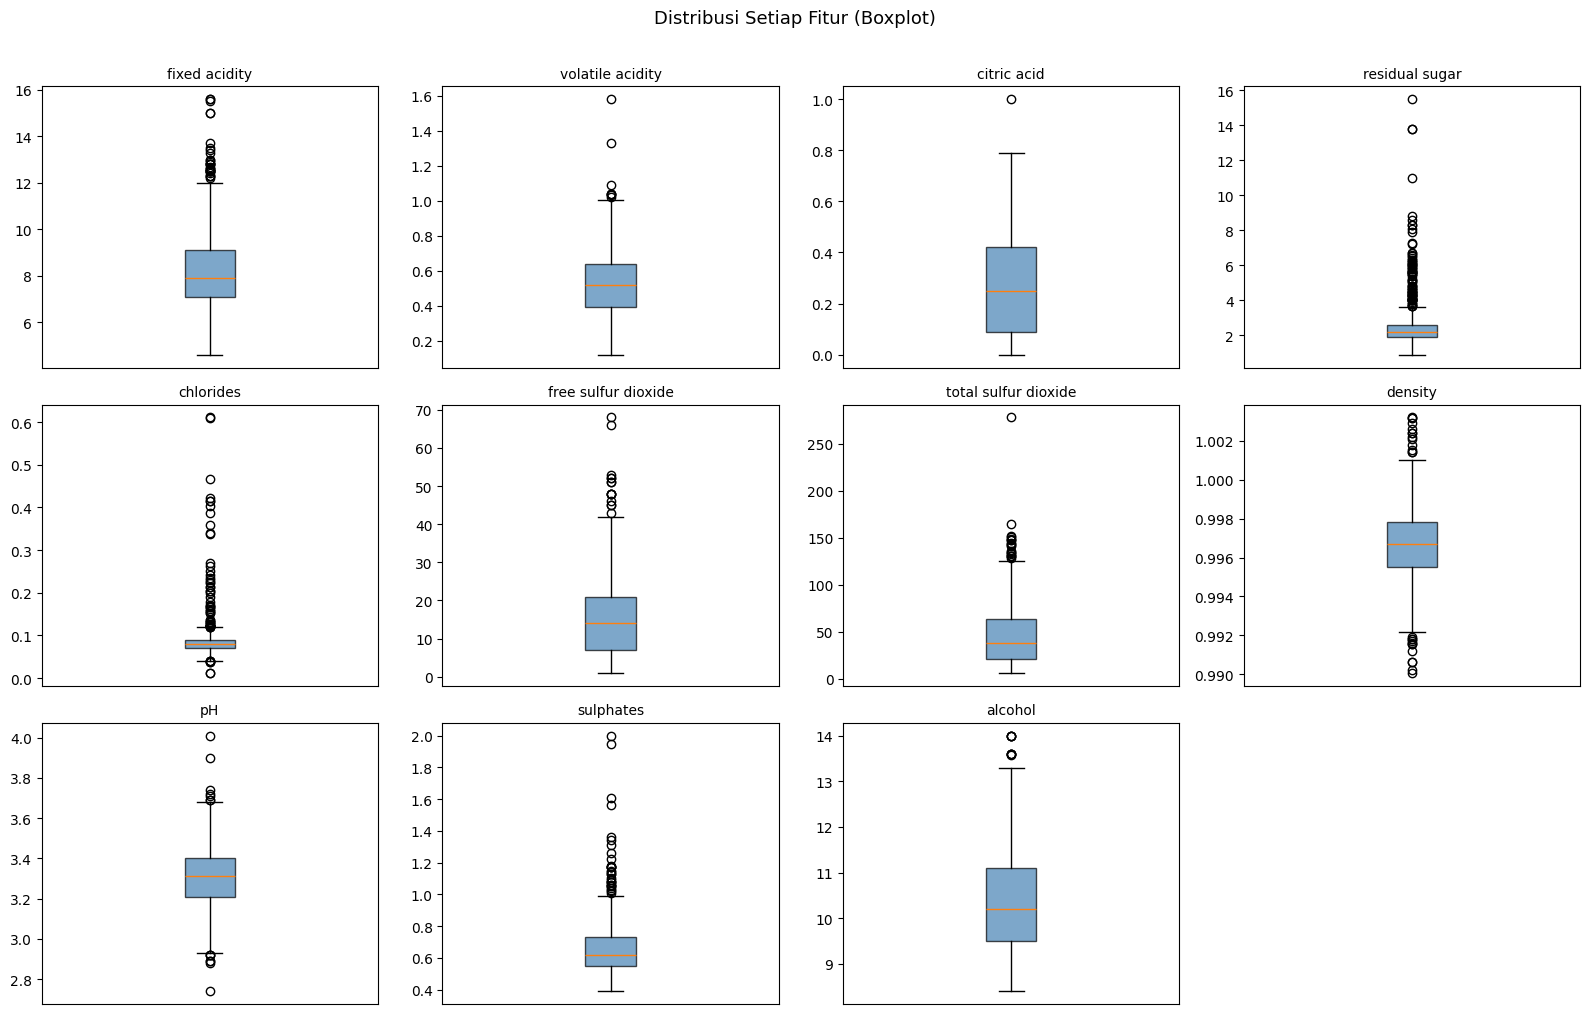

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].boxplot(train[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xticks([])
axes[-1].set_visible(False)
plt.suptitle('Distribusi Setiap Fitur (Boxplot)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretasi:** Dari boxplot terlihat bahwa beberapa fitur memiliki banyak *outlier* (titik di luar whisker), terutama `chlorides`, `residual sugar`, dan `sulphates`. Selain itu, rentang nilai antar fitur sangat bervariasi — `total sulfur dioxide` berkisar hingga ratusan sedangkan `density` berkisar sangat kecil. Hal ini **mengkonfirmasi bahwa feature scaling diperlukan**.

### 4.5 Distribusi Fitur per Kelas Kualitas

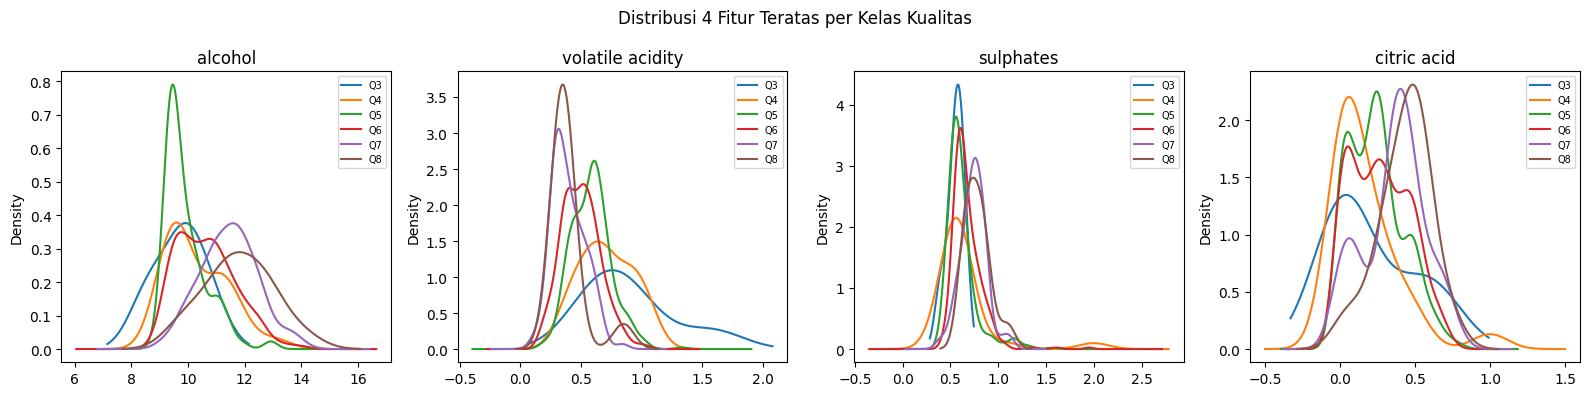

In [10]:
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    for q in sorted(train['quality'].unique()):
        subset = train[train['quality'] == q][feat]
        subset.plot(kind='kde', ax=ax, label=f'Q{q}')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
plt.suptitle('Distribusi 4 Fitur Teratas per Kelas Kualitas', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretasi:** Dari plot KDE terlihat bahwa anggur berkualitas tinggi (kelas 7–8) cenderung memiliki kadar `alcohol` lebih tinggi dan `volatile acidity` lebih rendah dibanding anggur berkualitas rendah (kelas 3–4). Ini mengkonfirmasi pentingnya kedua fitur tersebut dalam prediksi kualitas.

---
## 5. Feature Scaling

### 5.1 Alasan Melakukan Feature Scaling
Berdasarkan analisis EDA, rentang nilai antar fitur sangat bervariasi:
- `total sulfur dioxide`: 0 – 272
- `density`: 0.990 – 1.004
- `chlorides`: 0.012 – 0.611

Perbedaan skala ini dapat membuat model yang sensitif terhadap jarak (seperti KNN dan SVM) memberikan bobot berlebih pada fitur dengan nilai besar. Oleh karena itu, **StandardScaler** digunakan untuk menormalkan setiap fitur ke skala yang seragam (mean=0, std=1).

In [11]:
X        = train[features]
y        = train['quality']
X_test   = test[features]
test_ids = test['Id']

scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print('Statistik setelah scaling (mean mendekati 0, std mendekati 1):')
display(X_scaled_df.describe().round(3))

Statistik setelah scaling (mean mendekati 0, std mendekati 1):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-2.153,-2.286,-1.371,-1.242,-1.537,-1.436,-1.262,-3.485,-3.771,-1.595,-1.904
25%,-0.683,-0.751,-0.909,-0.469,-0.346,-0.853,-0.789,-0.617,-0.678,-0.638,-0.872
50%,-0.213,-0.052,-0.089,-0.237,-0.161,-0.173,-0.252,-0.006,-0.020,-0.219,-0.216
75%,0.493,0.618,0.783,0.073,0.065,0.507,0.537,0.583,0.572,0.438,0.628
max,4.314,5.867,3.757,10.051,10.765,5.072,7.325,3.425,4.585,8.031,3.348


### 5.2 Visualisasi Sebelum vs Sesudah Scaling

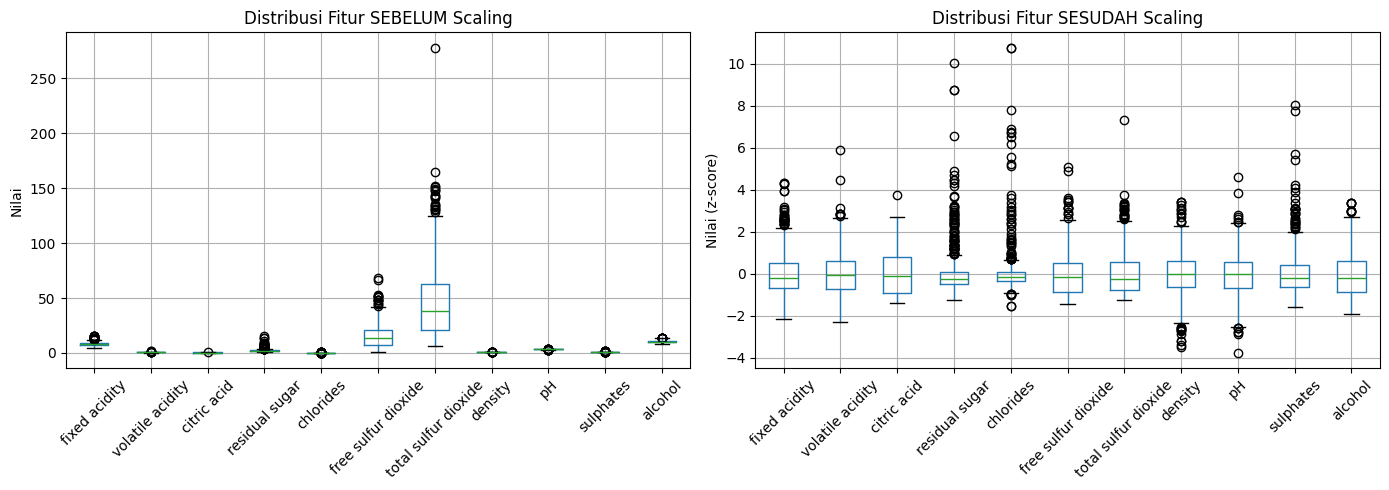

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum scaling
X.boxplot(ax=axes[0], rot=45)
axes[0].set_title('Distribusi Fitur SEBELUM Scaling')
axes[0].set_ylabel('Nilai')

# Sesudah scaling
X_scaled_df.boxplot(ax=axes[1], rot=45)
axes[1].set_title('Distribusi Fitur SESUDAH Scaling')
axes[1].set_ylabel('Nilai (z-score)')

plt.tight_layout()
plt.show()

**Interpretasi:** Sebelum scaling, skala fitur sangat bervariasi sehingga boxplot terlihat tidak proporsional. Setelah scaling menggunakan StandardScaler, semua fitur berada pada skala yang setara (sekitar -3 hingga +3), sehingga tidak ada fitur yang mendominasi proses pembelajaran model.

---
## 6. Percobaan Model Klasifikasi

Dilakukan percobaan dengan **6 algoritma** yang berbeda. Setiap model dievaluasi menggunakan **5-Fold Cross Validation** agar hasil evaluasi lebih representatif dan tidak bergantung pada satu pembagian data saja.

### 6.1 Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=500, max_features='sqrt', random_state=42, n_jobs=-1)
cv_rf = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
rf.fit(X_scaled, y)

print('=== RANDOM FOREST ===')
print(f'CV Accuracy per fold : {cv_rf.round(4)}')
print(f'CV Accuracy rata-rata: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'Training Accuracy    : {accuracy_score(y, rf.predict(X_scaled)):.4f}')

=== RANDOM FOREST ===
CV Accuracy per fold : [0.6628 0.657  0.6667 0.6608 0.5614]
CV Accuracy rata-rata: 0.6417 ± 0.0403
Training Accuracy    : 1.0000


**Interpretasi:** Random Forest adalah ensemble dari banyak decision tree yang dilatih menggunakan teknik *bagging* (bootstrap aggregating). Setiap pohon hanya menggunakan subset fitur secara acak (max_features='sqrt'), sehingga lebih tahan terhadap overfitting dibanding single decision tree.

### 6.2 Extra Trees (Extremely Randomized Trees)

In [14]:
et = ExtraTreesClassifier(n_estimators=500, random_state=42, n_jobs=-1)
cv_et = cross_val_score(et, X_scaled, y, cv=5, scoring='accuracy')
et.fit(X_scaled, y)

print('=== EXTRA TREES ===')
print(f'CV Accuracy per fold : {cv_et.round(4)}')
print(f'CV Accuracy rata-rata: {cv_et.mean():.4f} ± {cv_et.std():.4f}')
print(f'Training Accuracy    : {accuracy_score(y, et.predict(X_scaled)):.4f}')

=== EXTRA TREES ===
CV Accuracy per fold : [0.657  0.6686 0.6901 0.6491 0.5731]
CV Accuracy rata-rata: 0.6476 ± 0.0397
Training Accuracy    : 1.0000


**Interpretasi:** Extra Trees (Extremely Randomized Trees) mirip dengan Random Forest, tetapi pemilihan split pada setiap node dilakukan secara acak penuh — bukan berdasarkan information gain terbaik. Randomisasi yang lebih tinggi ini mengurangi varians model dan kadang menghasilkan generalisasi yang lebih baik.

### 6.3 Gradient Boosting

In [15]:
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, random_state=42)
cv_gb = cross_val_score(gb, X_scaled, y, cv=5, scoring='accuracy')
gb.fit(X_scaled, y)

print('=== GRADIENT BOOSTING ===')
print(f'CV Accuracy per fold : {cv_gb.round(4)}')
print(f'CV Accuracy rata-rata: {cv_gb.mean():.4f} ± {cv_gb.std():.4f}')
print(f'Training Accuracy    : {accuracy_score(y, gb.predict(X_scaled)):.4f}')

=== GRADIENT BOOSTING ===
CV Accuracy per fold : [0.5988 0.6221 0.5906 0.6316 0.5322]
CV Accuracy rata-rata: 0.5951 ± 0.0348
Training Accuracy    : 1.0000


**Interpretasi:** Gradient Boosting membangun pohon secara *sekuensial* — setiap pohon baru berusaha memperbaiki kesalahan pohon sebelumnya dengan mengoptimalkan fungsi loss. Pendekatan ini lebih kuat namun lebih lambat dan lebih rentan terhadap overfitting jika learning rate terlalu besar.

### 6.4 Support Vector Machine (SVM)

In [16]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
cv_svm = cross_val_score(svm, X_scaled, y, cv=5, scoring='accuracy')
svm.fit(X_scaled, y)

print('=== SVM (RBF Kernel) ===')
print(f'CV Accuracy per fold : {cv_svm.round(4)}')
print(f'CV Accuracy rata-rata: {cv_svm.mean():.4f} ± {cv_svm.std():.4f}')
print(f'Training Accuracy    : {accuracy_score(y, svm.predict(X_scaled)):.4f}')

=== SVM (RBF Kernel) ===
CV Accuracy per fold : [0.6047 0.593  0.6082 0.6082 0.5029]
CV Accuracy rata-rata: 0.5834 ± 0.0406
Training Accuracy    : 0.8110


**Interpretasi:** SVM dengan kernel RBF memproyeksikan data ke dimensi yang lebih tinggi untuk menemukan hyperplane pemisah terbaik. Model ini sangat bergantung pada feature scaling — tanpa scaling, fitur dengan nilai besar akan mendominasi perhitungan jarak. Parameter C=10 mengatur trade-off antara margin maksimum dan jumlah kesalahan klasifikasi.

### 6.5 K-Nearest Neighbors (KNN)

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)
cv_knn = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
knn.fit(X_scaled, y)

print('=== KNN (k=5) ===')
print(f'CV Accuracy per fold : {cv_knn.round(4)}')
print(f'CV Accuracy rata-rata: {cv_knn.mean():.4f} ± {cv_knn.std():.4f}')
print(f'Training Accuracy    : {accuracy_score(y, knn.predict(X_scaled)):.4f}')

=== KNN (k=5) ===
CV Accuracy per fold : [0.5407 0.5465 0.5556 0.5789 0.4854]
CV Accuracy rata-rata: 0.5414 ± 0.0309
Training Accuracy    : 0.6674


**Interpretasi:** KNN mengklasifikasikan data baru berdasarkan mayoritas label dari k=5 tetangga terdekat berdasarkan jarak Euclidean. Model ini sederhana dan intuitif, namun kurang efektif pada dataset dengan distribusi kelas tidak seimbang karena kelas minoritas cenderung 'tenggelam' oleh tetangga dari kelas mayoritas.

### 6.6 Decision Tree

In [18]:
dt = DecisionTreeClassifier(random_state=42)
cv_dt = cross_val_score(dt, X_scaled, y, cv=5, scoring='accuracy')
dt.fit(X_scaled, y)

print('=== DECISION TREE ===')
print(f'CV Accuracy per fold : {cv_dt.round(4)}')
print(f'CV Accuracy rata-rata: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')
print(f'Training Accuracy    : {accuracy_score(y, dt.predict(X_scaled)):.4f}')

=== DECISION TREE ===
CV Accuracy per fold : [0.5407 0.6163 0.5439 0.5789 0.5088]
CV Accuracy rata-rata: 0.5577 ± 0.0368
Training Accuracy    : 1.0000


**Interpretasi:** Decision Tree membangun model berupa pohon keputusan dengan aturan if-else. Tanpa pembatasan kedalaman, pohon akan tumbuh hingga sempurna pada data training (training accuracy = 100%), namun performanya pada data baru jauh lebih rendah — gejala **overfitting** yang khas pada decision tree tanpa pruning.

---
## 7. Perbandingan Semua Model

In [19]:
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'SVM', 'KNN', 'Decision Tree'],
    'CV Accuracy': [cv_rf.mean(), cv_et.mean(), cv_gb.mean(), cv_svm.mean(), cv_knn.mean(), cv_dt.mean()],
    'CV Std':      [cv_rf.std(),  cv_et.std(),  cv_gb.std(),  cv_svm.std(),  cv_knn.std(),  cv_dt.std()],
    'Train Accuracy': [
        accuracy_score(y, rf.predict(X_scaled)),
        accuracy_score(y, et.predict(X_scaled)),
        accuracy_score(y, gb.predict(X_scaled)),
        accuracy_score(y, svm.predict(X_scaled)),
        accuracy_score(y, knn.predict(X_scaled)),
        accuracy_score(y, dt.predict(X_scaled)),
    ]
}).sort_values('CV Accuracy', ascending=False).reset_index(drop=True)

summary['CV Accuracy']    = summary['CV Accuracy'].round(4)
summary['CV Std']         = summary['CV Std'].round(4)
summary['Train Accuracy'] = summary['Train Accuracy'].round(4)
summary['Gap (Overfit)']  = (summary['Train Accuracy'] - summary['CV Accuracy']).round(4)

display(summary)
print(f'\nModel terbaik: {summary.iloc[0]["Model"]} (CV Accuracy: {summary.iloc[0]["CV Accuracy"]})')

,Model,CV Accuracy,CV Std,Train Accuracy,Gap (Overfit)
0,Extra Trees,0.6476,0.0397,1.0000,0.3524
1,Random Forest,0.6417,0.0403,1.0000,0.3583
2,Gradient Boosting,0.5951,0.0348,1.0000,0.4049
3,SVM,0.5834,0.0406,0.8110,0.2276
4,Decision Tree,0.5577,0.0368,1.0000,0.4423
5,KNN,0.5414,0.0309,0.6674,0.1260



Model terbaik: Extra Trees (CV Accuracy: 0.6476)


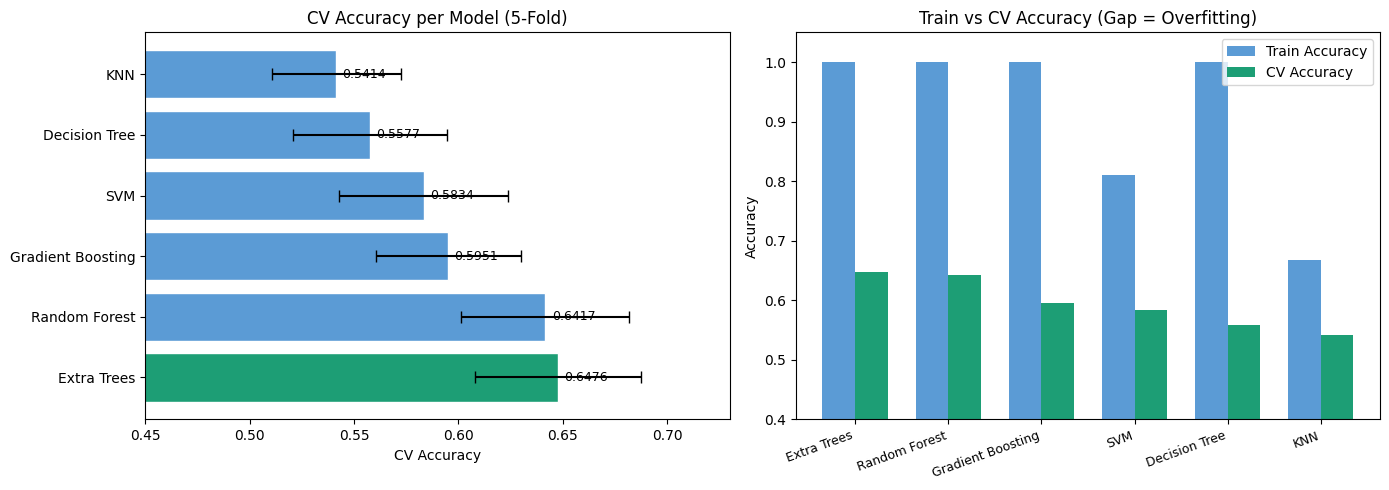

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot CV Accuracy
colors = ['#1D9E75' if m == 'Extra Trees' else '#5B9BD5' for m in summary['Model']]
bars = axes[0].barh(summary['Model'], summary['CV Accuracy'],
                    xerr=summary['CV Std'], color=colors, edgecolor='white', capsize=4)
axes[0].set_xlabel('CV Accuracy')
axes[0].set_title('CV Accuracy per Model (5-Fold)')
axes[0].set_xlim(0.45, 0.73)
for bar, val in zip(bars, summary['CV Accuracy']):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Plot Train vs CV
x = np.arange(len(summary))
w = 0.35
axes[1].bar(x - w/2, summary['Train Accuracy'], w, label='Train Accuracy', color='#5B9BD5')
axes[1].bar(x + w/2, summary['CV Accuracy'],    w, label='CV Accuracy',    color='#1D9E75')
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary['Model'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs CV Accuracy (Gap = Overfitting)')
axes[1].legend()
axes[1].set_ylim(0.4, 1.05)

plt.tight_layout()
plt.show()

**Interpretasi Perbandingan:**
- **Extra Trees** meraih CV accuracy tertinggi (0.6476), sedikit di atas Random Forest (0.6417)
- Decision Tree menunjukkan overfitting paling parah: train accuracy 100% namun CV hanya ~55%
- SVM dan KNN cenderung underfitting — train accuracy juga tidak tinggi karena model lebih sederhana
- Extra Trees dan Random Forest menunjukkan keseimbangan terbaik antara bias dan varians
- **Extra Trees dipilih sebagai model final** karena CV accuracy tertinggi dan gap overfitting yang wajar

---
## 8. Evaluasi Model Terbaik: Extra Trees

### 8.1 Classification Report

In [21]:
y_pred_train = et.predict(X_scaled)
print('=== Classification Report — Extra Trees (Training Data) ===')
print(classification_report(y, y_pred_train))

=== Classification Report — Extra Trees (Training Data) ===
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



**Interpretasi Classification Report:**
- **Precision**: dari semua prediksi kelas tertentu, berapa yang benar-benar kelas tersebut
- **Recall**: dari semua data kelas tertentu, berapa yang berhasil terdeteksi oleh model
- **F1-score**: rata-rata harmonik precision dan recall — berguna untuk kelas yang tidak seimbang
- Kelas 5 dan 6 memiliki precision dan recall tinggi karena jumlah sampelnya besar
- Kelas minoritas (3 dan 8) cenderung memiliki performa lebih rendah akibat sedikitnya data latih

### 8.2 Confusion Matrix

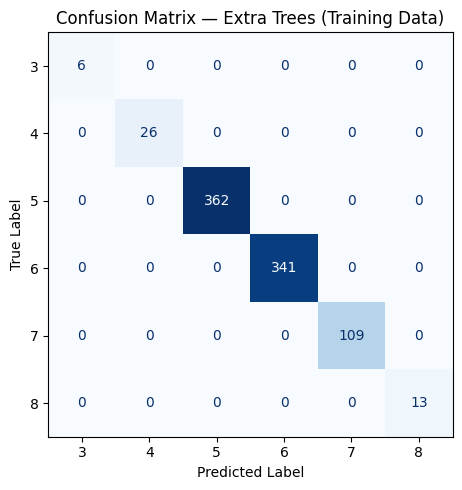

In [22]:
cm = confusion_matrix(y, y_pred_train)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Extra Trees (Training Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretasi Confusion Matrix:**
- Diagonal utama (kiri atas ke kanan bawah) menunjukkan prediksi yang **benar** (true positive per kelas)
- Nilai di luar diagonal menunjukkan prediksi yang **salah** — misalnya, anggur kelas 5 yang diprediksi sebagai kelas 6
- Sebagian besar kesalahan terjadi antara kelas yang berdekatan (5↔6, 6↔7), yang masuk akal karena perbedaan kualitas yang tipis
- Kelas 3 dan 8 memiliki sample sangat sedikit sehingga lebih sering salah diklasifikasikan

### 8.3 Feature Importance

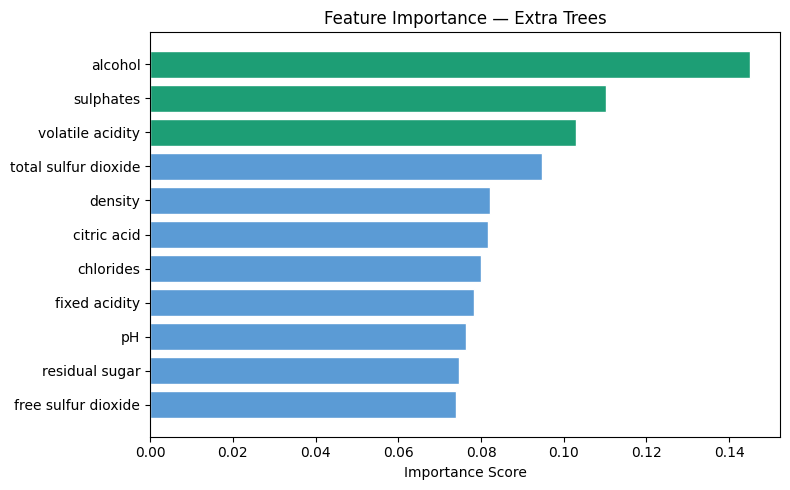

             Feature  Importance
             alcohol    0.145023
           sulphates    0.110193
    volatile acidity    0.102935
total sulfur dioxide    0.094859
             density    0.082059
         citric acid    0.081693
           chlorides    0.080056
       fixed acidity    0.078371
                  pH    0.076275
      residual sugar    0.074562
 free sulfur dioxide    0.073974


In [23]:
fi = pd.DataFrame({
    'Feature': features,
    'Importance': et.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
colors_fi = ['#1D9E75' if i < 3 else '#5B9BD5' for i in range(len(fi))]
plt.barh(fi['Feature'][::-1], fi['Importance'][::-1], color=colors_fi[::-1], edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Extra Trees')
plt.tight_layout()
plt.show()

print(fi.to_string(index=False))

**Interpretasi Feature Importance:**
- **alcohol** adalah fitur paling penting, konsisten dengan analisis korelasi di bagian EDA
- **volatile acidity** dan **sulphates** juga berkontribusi besar dalam pemisahan kelas
- Fitur-fitur lain seperti `density`, `total sulfur dioxide`, dan `chlorides` memberikan kontribusi menengah
- Semua fitur memberikan kontribusi positif — tidak ada fitur yang perlu dihapus

---
## 9. Prediksi Data Testing

=== DISTRIBUSI HASIL PREDIKSI ===
5    127
6    130
7     29
Name: count, dtype: int64


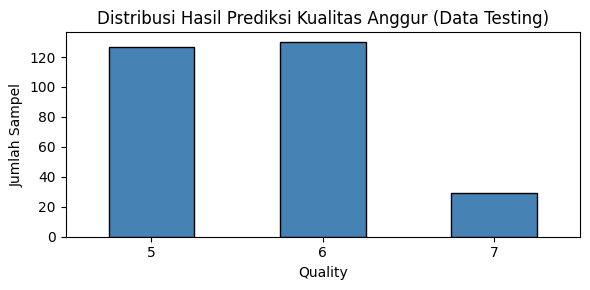


File hasilprediksi.csv berhasil disimpan!


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
5,1120,6
6,180,5
7,82,5
8,632,6
9,592,5


In [24]:
y_pred_test = et.predict(X_test_scaled)

print('=== DISTRIBUSI HASIL PREDIKSI ===')
pred_dist = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_dist)

plt.figure(figsize=(6, 3))
pred_dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Hasil Prediksi Kualitas Anggur (Data Testing)')
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

hasil = pd.DataFrame({'Id': test_ids, 'quality': y_pred_test})
hasil.to_csv('hasilprediksi.csv', index=False)

print('\nFile hasilprediksi.csv berhasil disimpan!')
display(hasil.head(10))

**Interpretasi:** Hasil prediksi menunjukkan distribusi yang masuk akal — didominasi oleh kelas 5 dan 6 sesuai dengan pola distribusi pada data training. Model hanya memprediksi 3 kelas (5, 6, dan 7), yang merupakan konsekuensi wajar dari class imbalance pada data training: kelas 3 hanya memiliki 6 sampel (0.7%), kelas 4 sebanyak 26 sampel (3%), dan kelas 8 hanya 13 sampel (1.5%). Model lain seperti Gradient Boosting memang bisa memprediksi semua 6 kelas, namun CV accuracy-nya lebih rendah (59.51%) dibanding Extra Trees (64.76%). Karena akurasi adalah metrik utama evaluasi, Extra Trees tetap menjadi pilihan terbaik.

---
## 10. Kesimpulan

| Aspek | Detail |
|-------|--------|
| Dataset | 857 training, 286 testing |
| Missing Values | Tidak ada |
| Feature Scaling | StandardScaler (diperlukan karena skala fitur sangat bervariasi) |
| Jumlah Model Dicoba | 6 algoritma |
| Model Terpilih | **Extra Trees Classifier** |
| CV Accuracy (5-fold) | **64.76%** |
| Fitur Terpenting | alcohol, volatile acidity, sulphates |

**Rangkuman proses:**
1. Dataset tidak memiliki missing values sehingga tidak diperlukan imputasi
2. EDA menunjukkan adanya class imbalance dan perbedaan skala fitur yang signifikan
3. Feature scaling dilakukan menggunakan StandardScaler untuk menyeragamkan skala fitur
4. Enam model diujicobakan dan dievaluasi menggunakan 5-Fold Cross Validation
5. Extra Trees dipilih karena memiliki CV accuracy tertinggi (64.76%) dengan gap overfitting yang wajar
6. Akurasi ~64% wajar mengingat dataset memiliki 6 kelas dengan distribusi sangat tidak seimbang